# Neural Network

3 parameters

In [1]:
######### LIBRARIES ############
# RICORDA DI ELIMINARE TUTTE LIBRERIE CHE NON UTILIZZI
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam,Nadam,Adamax
from ann_functions3D import getModel, kCrossVal, transfBestparam
from time import perf_counter
import pandas
import pickle
import os

seed = 7
np.random.seed(seed)

c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Introduction of the data

In [2]:
########################     PREPARATION      ##########################
HF_data = np.loadtxt("../DATA_shear_cube/3p/Data_Train_bases/HF_num_data.txt").astype(int) #list of number of HF data
Nlf_models = np.loadtxt("../DATA_shear_cube/3p/Data_Train_bases/N_bases.txt").astype(int)[0:2]
HF_data_str = [str(num) for num in HF_data]
r2_HF_df = pandas.DataFrame(index=HF_data_str)             #dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame()                              #dataframe which stores LF R^2

mse_HF_df = pandas.DataFrame(index=HF_data_str)            #dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame()                             #dataframe which stores LF MSE

U_HF_list  = []
U_LF_list  = []


In [3]:
#########################     TRAIN SET      ##########################
mu_train_LF = np.loadtxt("../DATA_shear_cube/3p/Data_Train_bases/mu_train_LF.txt")
Nlf = np.size(mu_train_LF)    # number of low-fidelity data to TRAIN the NN

U_lf_train_full = np.loadtxt("../DATA_shear_cube/3p/Data_Train_bases/Ulf_train.txt")[:,0:2]

NepoLF = 3000   # number of epochs for first NN: NN_LF
NepoHF = 3000   # number of epochs for third NN: NN_HF

# NB su codice di paolo il numero di steps è diverso wrt hyperparams research. PErchè?

In [4]:
#########################     TEST SET      ##########################
mu_test = np.loadtxt("../DATA_shear_cube/3p/Data_Test_bases/mu_test.txt")
N_test = np.size(mu_test)

U_lf_test_full = np.loadtxt("../DATA_shear_cube/3p/Data_Test_bases/Ulf_test.txt")[:,0:2]

# ADD NOISE

permutation = np.random.permutation(len(mu_train_LF))
mu_train_LF=mu_train_LF[permutation,:][0:10,:]

#noise_stddev = np.mean(mu_train_LF,axis=0)*0.1
#noise = np.random.normal(0, noise_stddev, np.shape(mu_train_LF))
#mu_train_LF=mu_train_LF+noise 

Nlf = np.size(mu_train_LF)  #number of low-fidelity data to TRAIN the NN

U_lf_train_full=U_lf_train_full[permutation][0:10,:]


In [5]:
#Input
mu_max = np.max(mu_test,axis=0)
mu_min = np.min(mu_test,axis=0)

mu_test_norm = (mu_test - mu_min) / (mu_max - mu_min)
mu_train_LF_norm = (mu_train_LF - mu_min) / (mu_max - mu_min)

U_t_max_train=np.max(U_lf_train_full)
U_t_min_train=np.min(U_lf_train_full)

U_t_max_test=np.max(U_lf_test_full)
U_t_min_test=np.min(U_lf_test_full)

U_train_LF_full=(U_lf_train_full-U_t_min_train)/(U_t_max_test-U_t_min_test)
U_test_LF_full=(U_lf_test_full-U_t_min_test)/(U_t_max_test-U_t_min_test)

#noise_stddev = np.mean(U_lf_train_full,axis=0)*0.1
#noise = np.random.normal(0, noise_stddev, np.shape(U_lf_train_full))
#U_lf_train_full=U_lf_train_full+noise

In [6]:
for m in range(len(Nlf_models)):
# loop over the basis    
        print(f"********************  #basis functions = {Nlf_models[m]}  ********************")
        
        test_mse_HF_list  = []
        test_mse_LF_list  = []

        r2_HF_list  = []
        r2_LF_list  = []
        
        #########################     TRAIN SET      ##########################
        U_train_LF=U_train_LF_full[:,m]
        
        #########################     TRAIN SET      ##########################
        U_test_LF=U_test_LF_full[:,m]
        
        ##########################     NORMALIZATION  ##########################
        #Output
        #lfmean = np.mean(U_test_LF)        # PERCHE LA MEDIA SOLO DI U_test_LF ???????????????????

        #U_train_LF = U_train_LF - lfmean
        #U_test_LF = U_test_LF - lfmean
        
        #U_train_LF= np.exp(U_train_LF*100)*1e-6
        #U_test_LF = np.exp(U_test_LF*100)*1e-6
        
        ##########################       FIRST NN: NN_LF     ##########################
        K.clear_session()
        bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}  # <------------------ 

        modelLF = getModel(bestLF_params,'LF')     # ann_functions
        histLF = modelLF.fit(mu_train_LF_norm, U_train_LF ,epochs=NepoLF,batch_size=Nlf, verbose = 0)
#        histLF = modelLF.fit(Young_LF_norm[:,0], U_train_LF ,epochs=NepoLF,batch_size=Nlf, verbose = 0)
# attenzione -> QUANDO LO FARAI IN PIU DIMENSIONI DI INPUT QUESTA PARTE E' DA SCRIVERE TENENDO CONTO DELLE DIMNSIONI EFFETTIVE DELLA MATRICE DI INPUT, DATO CHE NON POTRAI TAGLIARE ALL'INIZIO
        print('LF NN done')

        ULF = modelLF.predict(mu_test_norm)
        
        U_LF_list.append(ULF)
        print('\nLF Model:')

        test_mse = np.mean(np.square(U_test_LF - ULF[:,0]))
        test_mse_LF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r_2 = 1 - np.sum(np.square(U_test_LF - ULF[:,0])) / np.sum(np.square(U_test_LF - np.mean(U_test_LF)))
        r2_LF_list.append(r_2)
        print(f"R^2: {r_2}")

        
        for n_HF in HF_data:
        #loop over the possible numbers of high-fidelity data

                print(f"\n-------  #HF data = {n_HF}  -------")
                start = perf_counter()

                n_HF_txt = str(n_HF) + '.txt'

                #########################     TRAIN SET      #########################
                mu_train_HF = np.loadtxt("../DATA_shear_cube/3p/Data_Train_bases/mu_train_HF_" + n_HF_txt)   # serve quando si provano diverso numero di dati                  
                Nhf = np.size(mu_train_HF)  # number of high-fidelity data to TRAIN the NN
# APPUNTO: cambiare nome a U_hf, per adattarlo a scrittura Uhf?
                U_hf_train = np.loadtxt("../DATA_shear_cube/3p/Data_Train_bases/Uhf_train_" + n_HF_txt)      # ""
                
                permutation = np.random.permutation(len(mu_train_HF))  # <---
                mu_train_HF=mu_train_HF[permutation][0:5]              # <--
                U_hf_train=U_hf_train[permutation][0:5]                # <--
                
                #########################     TEST SET      ##########################
                U_hf_test = np.loadtxt("../DATA_shear_cube/3p/Data_Test_bases/Uhf_test.txt")

                ##########################     NORMALIZATION  ##########################
                # TRANSFORMATION
#                U_hf_train = np.exp(U_hf_train*100)*1e-6
#                U_hf_test = np.exp(U_hf_test*100)*1e-6
                
                #Input
                mu_train_HF_norm = (mu_train_HF - mu_min) / (mu_max - mu_min)

                #Output
                #hfmean = np.mean(U_hf_test)

                #U_hf_train = U_hf_train - hfmean
                #U_hf_test = U_hf_test - hfmean
                
                U_t_min_test=np.min(U_hf_test,axis=0)
                U_t_max_test=np.max(U_hf_test,axis=0)
                
                U_t_min_train=np.min(U_hf_train,axis=0)
                U_t_max_train=np.max(U_hf_train,axis=0)
                
                U_hf_train=(U_hf_train-U_t_min_train)/(U_t_max_train-U_t_min_train)
                U_hf_test=(U_hf_test-U_t_min_test)/(U_t_max_test-U_t_min_test)

                ##########################    SECOND NN: NN_HF    ##########################
                mu_test_help = modelLF.predict(mu_test_norm)[:,0]
                mu_test_in = np.vstack((mu_test_norm.transpose(),mu_test_help)).transpose() # <- TEST INPUT for the second NN: NN_HF

                mu_train_help = modelLF.predict(mu_train_HF_norm)[:,0] #f_LF(mu_hf_train)
                mu_final = np.vstack((mu_train_HF_norm.transpose(),mu_train_help)).transpose() # <- TRAINING INPUT for the second NN: NN_HF

                name = '2step'
                K.clear_session()
                #best paramters obtained by HPO:
                # Young
                #best_param = {'kernel_init': 'uniform', 'l2weight': 0.00012051711558537875, 'lr': 0.0017624104175516413, 'nodes': 18.0, 'opt': 'Adamax'}
                #best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010669470437554761, 'lr': 0.015298517193401867, 'nodes': 12.0, 'opt': 'Adamax'}
                #best_params={'kernel_init': 'uniform', 'l2weight': 0.00021280958667909701, 'lr': 0.01280013966561744, 'nodes': 6.0, 'opt': 'Adam'}
                # Poisson
                best_params={'kernel_init': 'uniform', 'l2weight': 0.00014792980965688785, 'lr': 0.00033536498844198136, 'nodes': 56.0, 'opt': 'Adam'}
                #100%|██████████| 15/15 [28:24<00:00, 113.64s/trial, best loss: 4.971638652351829e-06] {'kernel_init': 'uniform', 'l2weight': 0.000807831416040378, 'lr': 0.0052322673829551325, 'nodes': 48.0, 'opt': 'Adam'
                finalModel = getModel(best_params,name) #final model chosen according to the best paramters
                hist = finalModel.fit(mu_final, U_hf_train, validation_data=(mu_test_in, U_hf_test),epochs=NepoHF,batch_size=Nhf,verbose=0, validation_freq = 20)

                UHF = finalModel.predict(mu_test_in)
                U_HF_list.append(UHF)

                stop = perf_counter()
                elapsed = stop - start
                print('Elapsed time: ', elapsed)
                print('\nHF Model:')

                test_mse = np.mean(np.square(U_hf_test - UHF[:,0]))
                test_mse_HF_list.append(test_mse)
                print(f"Test MSE: {test_mse}")

                r2_HF = 1 - np.sum(np.square(U_hf_test - UHF[:,0])) / np.sum(np.square(U_hf_test - np.mean(U_hf_test)))
                r2_HF_list.append(r2_HF)
                print(f"R^2: {r2_HF}")        
        
        
        r2_LF_df[str(Nlf_models[m])] = r2_LF_list
        r2_HF_df[str(Nlf_models[m])] = r2_HF_list

        mse_LF_df[str(Nlf_models[m])] = test_mse_LF_list
        mse_HF_df[str(Nlf_models[m])] = test_mse_HF_list      

print(r2_HF_df.round(5))
print(mse_HF_df.round(5))  

********************  #basis functions = 7  ********************


LF NN done
4/4 [==============================] - 0s 6ms/step

LF Model:
Test MSE: 0.000620606402622923
R^2: 0.9909594684576686

-------  #HF data = 5  -------
4/4 [==============================] - 0s 6ms/step
Elapsed time:  20.551667400053702

HF Model:
Test MSE: 0.07180212825999709
R^2: -0.0462911268165167

-------  #HF data = 7  -------
4/4 [==============================] - 0s 6ms/step
Elapsed time:  18.821694800048135

HF Model:
Test MSE: 0.07082861775369353
R^2: -0.03210526033467964

-------  #HF data = 9  -------
4/4 [==============================] - 0s 6ms/step
Elapsed time:  19.268151700031012

HF Model:
Test MSE: 0.058309443568193016
R^2: 0.15032249191702096

-------  #HF data = 11  -------
4/4 [==============================] - 0s 7ms/step
Elapsed time:  21.058921299991198

HF Model:
Test MSE: 0.005874687068235947
R^2: 0.9143948361800375

-------  #HF data = 13  -------
4/4 [==============================] - 0s 0s/step
Elapsed time:  19.759263100102544

HF Model:
Test MSE:

In [8]:
print(mu_test_help[:,0])

[0.7284311  0.83439684 0.38682854 0.8021524  0.20214799 0.5258984
 0.77117276 0.78934723 0.22397204 0.3248539  0.4635257  0.3628415
 0.4494567  0.9692452  0.5450555  0.8091537  0.33296004 0.42592317
 0.676815   0.64756215 0.41050428 0.1461778  0.20328434 0.7047582
 0.5995324  0.01344429 0.45292687 0.51784045 0.06854473 0.23911735
 0.78369    0.07996414 0.74695075 0.73624897 0.04607587 0.3395174
 0.29898918 0.3844054  0.09937055 0.17943819 0.8037174  0.9070766
 0.4191253  0.57164437 0.17739005 0.2596967  0.0644322  0.30343068
 0.20330226 0.8548363  0.31328732 0.7374252  0.56381917 0.47048557
 0.3725505  0.52660215 0.0754015  0.58584714 0.82075286 0.0317293
 0.68899095 0.6108555  0.9349542  0.34525114 0.8445821  0.449726
 0.10984232 0.29333025 0.6359229  0.62354875 0.09085622 0.38276714
 0.34915507 0.8238641  0.29687947 0.7577532  0.31769812 0.77028394
 0.17658688 0.6540346  0.01636201 0.5130511  0.43007696 0.25300965
 0.22808772 0.5783333  0.2632505  0.36849093 0.12509045 0.20796165
 0.

4/4 [==============================] - 0s 5ms/step


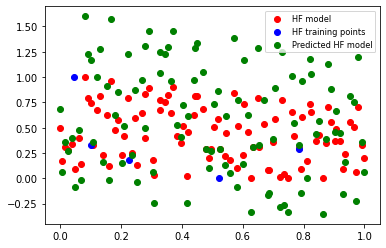

4/4 [==============================] - 0s 2ms/step


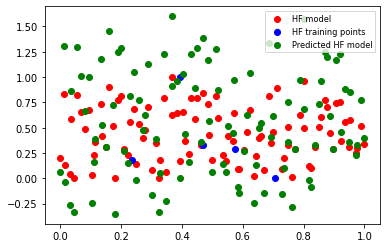

4/4 [==============================] - 0s 2ms/step


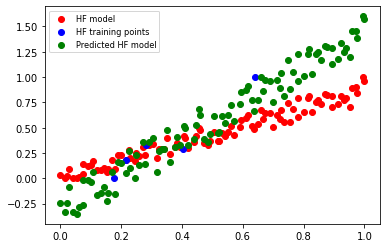

In [ ]:
plt.figure()
plt.scatter(mu_test_in[:,0], U_hf_test,color='red', label = 'HF model')
plt.scatter(mu_final[:,0], U_hf_train,color='blue', label = 'HF training points')
plt.scatter(mu_test_in[:,0], finalModel.predict(mu_test_in),color='green', label = 'Predicted HF model')
plt.legend(prop={'size': 8.3})
plt.show()

plt.figure()
plt.scatter(mu_test_in[:,1], U_hf_test,color='red', label = 'HF model')
plt.scatter(mu_final[:,1], U_hf_train,color='blue', label = 'HF training points')
plt.scatter(mu_test_in[:,1], finalModel.predict(mu_test_in), color='green', label = 'Predicted HF model')
plt.legend(prop={'size': 8.3})
plt.show()

plt.figure()
plt.scatter(mu_test_in[:,2], U_hf_test,color='red', label = 'HF model')
plt.scatter(mu_final[:,2], U_hf_train,color='blue', label = 'HF training points')
plt.scatter(mu_test_in[:,2], finalModel.predict(mu_test_in),color='green', label = 'Predicted HF model')
plt.legend(prop={'size': 8.3})
plt.show()

In [8]:
#########################     SAVE the OUTPUT      ##########################
os.makedirs('Output_MF_rel_no_noise')

r2_HF_df.to_csv('./Output_MF_rel_no_noise/r2_HF_lhs_transformation.txt', header=True, index=False, sep='\t', mode='a')
mse_HF_df.to_csv('./Output_MF_rel_no_noise/mse_HF_lhs_transformation.txt', header = True, index = False, sep = '\t', mode = 'a')
r2_LF_df.to_csv('./Output_MF_rel_no_noise/r2_LF_lhs_transformation.txt', header=True, index=False, sep='\t', mode='a')
mse_LF_df.to_csv('./Output_MF_rel_no_noise/mse_LF_lhs_transformation.txt', header = True, index = False, sep = '\t', mode = 'a')


FileExistsError: [WinError 183] Impossibile creare un file, se il file esiste già: 'Output_MF_rel_no_noise'